# Model estimation and forecasting

## Define paths, returns, samples, and proxy for volatility

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
DATA_PATH = Path("../data_clean/btc_daily_returns.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")

df.head()

,price,log_return
Date,,
2016-01-02,433.437988,-0.206512
2016-01-03,430.010986,-0.793798
2016-01-04,433.091003,0.713712
2016-01-05,431.959991,-0.261490
2016-01-06,429.105011,-0.663130


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 3803 entries, 2016-01-02 to 2026-05-31
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       3803 non-null   float64
 1   log_return  3803 non-null   float64
dtypes: float64(2)
memory usage: 89.1 KB
None


In [4]:
returns = df["log_return"].dropna()
returns.name = "BTC daily log return (%)"

returns.head()

Date
2016-01-02   -0.206512
2016-01-03   -0.793798
2016-01-04    0.713712
2016-01-05   -0.261490
2016-01-06   -0.663130
Name: BTC daily log return (%), dtype: float64

In [5]:
OUT_OF_SAMPLE_FRACTION = 0.20

n_obs = len(returns)
split_idx = int(np.floor((1 - OUT_OF_SAMPLE_FRACTION) * n_obs))

returns_in = returns.iloc[:split_idx].copy()
returns_out = returns.iloc[split_idx:].copy()

print(f"Total number of return observations: {n_obs}")
print(f"In-sample observations:             {len(returns_in)}")
print(f"Out-of-sample observations:         {len(returns_out)}")
print()
print(f"In-sample period:     {returns_in.index.min().date()} to {returns_in.index.max().date()}")
print(f"Out-of-sample period: {returns_out.index.min().date()} to {returns_out.index.max().date()}")

Total number of return observations: 3803
In-sample observations:             3042
Out-of-sample observations:         761

In-sample period:     2016-01-02 to 2024-04-30
Out-of-sample period: 2024-05-01 to 2026-05-31


In [6]:
mean_return_in = returns_in.mean()

volatility_proxy_out = (returns_out - mean_return_in) ** 2
volatility_proxy_out.name = "realised_volatility_proxy"

print(f"In-sample mean return: {mean_return_in:.6f}")
print()
print(volatility_proxy_out.head())

In-sample mean return: 0.162355

Date
2024-05-01    17.400140
2024-05-02     1.739983
2024-05-03    36.160564
2024-05-04     2.010098
2024-05-05     0.003136
Name: realised_volatility_proxy, dtype: float64


## Generalized model estimation workflow of ARCH-family models

In [7]:
# imprt required packages
import arch
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

In [8]:
def fit_volatility_model(
    returns_series,
    model_name,
    volatility_model,
    p,
    o=0,
    q=0,
    distribution="normal",
    distribution_name=None,
    mean_model="Constant",
    rescale=False,
    cov_type="classic"
):
    """
    Estimate one ARCH-family volatility model.

    Parameters
    ----------
    returns_series : pandas.Series
        Return series used for model estimation.
    model_name : str
        Readable model name, for example "ARCH(1)" or "GARCH(1,1)".
    volatility_model : str
        Volatility model type used by the arch package:
        "ARCH", "GARCH", or "EGARCH".
    p : int
        Number of ARCH terms.
    o : int, optional
        Number of asymmetric terms. Relevant for EGARCH.
    q : int, optional
        Number of lagged conditional variance terms.
    distribution : str, optional
        Distribution code used by the arch package:
        "normal", "t", "ged", or "skewt".
    distribution_name : str, optional
        Readable distribution name used in output tables.
    mean_model : str, optional
        Conditional mean specification. We use "Constant".
    rescale : bool, optional
        Whether the arch package may internally rescale the data.
        We use False because returns are already expressed in percentages.
    cov_type : str, optional
        Covariance estimator for standard errors.

    Returns
    -------
    result : arch.univariate.base.ARCHModelResult
        Fitted model result.
    """

    model = arch_model(
        y=returns_series,
        mean=mean_model,
        vol=volatility_model,
        p=p,
        o=o,
        q=q,
        dist=distribution,
        rescale=rescale
    )

    result = model.fit(
        disp="off",
        cov_type=cov_type
    )

    # Store readable metadata for later tables.
    result.model_name = model_name
    result.distribution_name = distribution_name
    result.distribution_code = distribution
    result.volatility_model_name = volatility_model
    result.p = p
    result.o = o
    result.q = q

    return result

In [9]:
def extract_parameter_table(result):
    """
    Extract parameter estimates, standard errors, t-values and p-values
    from an estimated ARCH-family model.

    Parameters
    ----------
    result : arch.univariate.base.ARCHModelResult
        The fitted model result.

    Returns
    -------
    parameter_table : pandas.DataFrame
        Table with one row per estimated parameter.
    """

    parameter_table = pd.DataFrame({
        "model": result.model_name,
        "distribution": result.distribution_name,
        "parameter": result.params.index,
        "estimate": result.params.values,
        "std_error": result.std_err.values,
        "t_value": result.tvalues.values,
        "p_value": result.pvalues.values
    })

    return parameter_table

In [10]:
def extract_model_info(result):
    """
    Extract log-likelihood, AIC, BIC and related model information.

    Parameters
    ----------
    result : arch.univariate.base.ARCHModelResult
        The fitted model result.

    Returns
    -------
    model_info : pandas.Series
        Summary information for one estimated model.
    """

    model_info = pd.Series({
        "model": result.model_name,
        "distribution": result.distribution_name,
        "log_likelihood": result.loglikelihood,
        "aic": result.aic,
        "bic": result.bic,
        "n_obs": result.nobs,
        "num_params": result.num_params,
        "convergence_flag": result.convergence_flag
    })

    return model_info

In [11]:
def extract_fitted_series(result, returns_series):
    """
    Extract residuals, fitted conditional volatility, conditional variance,
    and standardized residuals from an estimated model.

    Parameters
    ----------
    result : arch.univariate.base.ARCHModelResult
        The fitted model result.
    returns_series : pandas.Series
        The return series used in estimation.

    Returns
    -------
    fitted : pandas.DataFrame
        DataFrame containing fitted quantities for one model.
    """

    residuals = result.resid
    conditional_volatility = result.conditional_volatility
    conditional_variance = conditional_volatility ** 2
    standardized_residuals = residuals / conditional_volatility

    fitted = pd.DataFrame({
        "return": returns_series,
        "residual": residuals,
        "conditional_volatility": conditional_volatility,
        "conditional_variance": conditional_variance,
        "standardized_residual": standardized_residuals
    })

    fitted = fitted.dropna()

    return fitted

In [12]:
def run_residual_diagnostics(
    result,
    fitted_series,
    diagnostic_lags=(10, 20, 30),
    arch_lm_lags=10
):
    """
    Run Ljung-Box tests and ARCH-LM test on standardized residuals.

    Parameters
    ----------
    result : arch.univariate.base.ARCHModelResult
        The fitted model result.
    fitted_series : pandas.DataFrame
        Output from extract_fitted_series().
    diagnostic_lags : tuple of int
        Lags used for Ljung-Box tests.
    arch_lm_lags : int
        Number of lags used in the ARCH-LM test.

    Returns
    -------
    diagnostics : dict
        Dictionary containing Ljung-Box and ARCH-LM diagnostic results.
    """

    std_resid = fitted_series["standardized_residual"].dropna()
    std_resid_sq = std_resid ** 2

    # Ljung-Box test on standardized residuals.
    lb_std_resid = acorr_ljungbox(
        std_resid,
        lags=list(diagnostic_lags),
        return_df=True
    )

    lb_std_resid = lb_std_resid.rename(columns={
        "lb_stat": "lb_stat_standardized_residual",
        "lb_pvalue": "lb_pvalue_standardized_residual"
    })

    # Ljung-Box test on squared standardized residuals.
    lb_std_resid_sq = acorr_ljungbox(
        std_resid_sq,
        lags=list(diagnostic_lags),
        return_df=True
    )

    lb_std_resid_sq = lb_std_resid_sq.rename(columns={
        "lb_stat": "lb_stat_squared_standardized_residual",
        "lb_pvalue": "lb_pvalue_squared_standardized_residual"
    })

    ljung_box_table = pd.concat(
        [lb_std_resid, lb_std_resid_sq],
        axis=1
    )

    ljung_box_table.index.name = "lag"
    ljung_box_table.insert(0, "model", result.model_name)
    ljung_box_table.insert(1, "distribution", result.distribution_name)

    # ARCH-LM test for remaining ARCH effects.
    arch_lm_stat, arch_lm_pvalue, arch_lm_f_stat, arch_lm_f_pvalue = het_arch(
        std_resid,
        nlags=arch_lm_lags,
        ddof=result.num_params
    )

    arch_lm_table = pd.Series({
        "model": result.model_name,
        "distribution": result.distribution_name,
        "lags": arch_lm_lags,
        "lm_stat": arch_lm_stat,
        "lm_pvalue": arch_lm_pvalue,
        "f_stat": arch_lm_f_stat,
        "f_pvalue": arch_lm_f_pvalue
    })

    diagnostics = {
        "ljung_box": ljung_box_table,
        "arch_lm": arch_lm_table
    }

    return diagnostics

In [13]:
DIAGNOSTIC_LAGS = [10, 20, 30]
ARCH_LM_LAGS = 10

test_result = fit_volatility_model(
    returns_series=returns_in,
    model_name="ARCH(1)",
    volatility_model="ARCH",
    p=1,
    o=0,
    q=0,
    distribution="normal"
)

test_parameter_table = extract_parameter_table(test_result)
test_model_info = extract_model_info(test_result)
test_fitted_series = extract_fitted_series(test_result, returns_in)
test_diagnostics = run_residual_diagnostics(
    result=test_result,
    fitted_series=test_fitted_series,
    diagnostic_lags=DIAGNOSTIC_LAGS,
    arch_lm_lags=ARCH_LM_LAGS
)

print(test_model_info)
print()
print(test_parameter_table)
print()
print(test_diagnostics["ljung_box"])
print()
print(test_diagnostics["arch_lm"])

model                    ARCH(1)
distribution                None
log_likelihood      -8255.223415
aic                  16516.44683
bic                 16534.507642
n_obs                       3042
num_params                     3
convergence_flag               0
dtype: object

     model distribution parameter   estimate  std_error    t_value  \
0  ARCH(1)         None        mu   0.185263   0.064805   2.858785   
1  ARCH(1)         None     omega  11.671028   0.363500  32.107330   
2  ARCH(1)         None  alpha[1]   0.164859   0.025733   6.406575   

         p_value  
0   4.252668e-03  
1  3.483574e-226  
2   1.488250e-10  

       model distribution  lb_stat_standardized_residual  \
lag                                                        
10   ARCH(1)         None                      13.016149   
20   ARCH(1)         None                      20.445164   
30   ARCH(1)         None                      32.874936   

     lb_pvalue_standardized_residual  lb_stat_squared_standard

## Estimating model and distribution combinations

In [14]:
model_grid = [
    {
        "model_name": "ARCH(1)",
        "volatility_model": "ARCH",
        "p": 1,
        "o": 0,
        "q": 0
    },
    {
        "model_name": "ARCH(2)",
        "volatility_model": "ARCH",
        "p": 2,
        "o": 0,
        "q": 0
    },
    {
        "model_name": "ARCH(3)",
        "volatility_model": "ARCH",
        "p": 3,
        "o": 0,
        "q": 0
    },
    {
        "model_name": "GARCH(1,1)",
        "volatility_model": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1
    },
    {
        "model_name": "EGARCH(1,1)",
        "volatility_model": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1
    }
]


distribution_grid = [
    {
        "distribution_name": "Normal",
        "distribution": "normal"
    },
    {
        "distribution_name": "Student-t",
        "distribution": "t"
    },
    {
        "distribution_name": "GED",
        "distribution": "ged"
    },
    {
        "distribution_name": "Skewed Student-t",
        "distribution": "skewt"
    }
]

In [15]:
estimation_grid = [
    {**model_spec, **distribution_spec}
    for model_spec in model_grid
    for distribution_spec in distribution_grid
]

estimation_grid_table = pd.DataFrame(estimation_grid)

estimation_grid_table

,model_name,volatility_model,p,o,q,distribution_name,distribution
0,ARCH(1),ARCH,1,0,0,Normal,normal
1,ARCH(1),ARCH,1,0,0,Student-t,t
2,ARCH(1),ARCH,1,0,0,GED,ged
3,ARCH(1),ARCH,1,0,0,Skewed Student-t,skewt
4,ARCH(2),ARCH,2,0,0,Normal,normal
5,ARCH(2),ARCH,2,0,0,Student-t,t
6,ARCH(2),ARCH,2,0,0,GED,ged
7,ARCH(2),ARCH,2,0,0,Skewed Student-t,skewt
8,ARCH(3),ARCH,3,0,0,Normal,normal
9,ARCH(3),ARCH,3,0,0,Student-t,t


In [16]:
model_results = {}
parameter_tables = []
model_info_rows = []
fitted_series_dict = {}
ljung_box_tables = []
arch_lm_rows = []

for specification in estimation_grid:
    
    model_name = specification["model_name"]
    distribution_name = specification["distribution_name"]
    model_key = f"{model_name} | {distribution_name}"
    
    print(f"Estimating {model_key}...")
    
    
    result = fit_volatility_model(
        returns_series=returns_in,
        model_name=model_name,
        volatility_model=specification["volatility_model"],
        p=specification["p"],
        o=specification["o"],
        q=specification["q"],
        distribution=specification["distribution"],
        distribution_name=distribution_name
    )
        
    fitted_series = extract_fitted_series(
        result=result,
        returns_series=returns_in
    )
        
    diagnostics = run_residual_diagnostics(
        result=result,
        fitted_series=fitted_series,
        diagnostic_lags=DIAGNOSTIC_LAGS,
        arch_lm_lags=ARCH_LM_LAGS
    )
        
    model_results[model_key] = result
    fitted_series_dict[model_key] = fitted_series
        
    parameter_tables.append(extract_parameter_table(result))
    model_info_rows.append(extract_model_info(result))
    ljung_box_tables.append(diagnostics["ljung_box"])
    arch_lm_rows.append(diagnostics["arch_lm"])
        

print()
print("Model estimation loop completed.")
print(f"Successfully estimated models: {len(model_results)}")

Estimating ARCH(1) | Normal...
Estimating ARCH(1) | Student-t...
Estimating ARCH(1) | GED...
Estimating ARCH(1) | Skewed Student-t...
Estimating ARCH(2) | Normal...
Estimating ARCH(2) | Student-t...
Estimating ARCH(2) | GED...
Estimating ARCH(2) | Skewed Student-t...
Estimating ARCH(3) | Normal...
Estimating ARCH(3) | Student-t...
Estimating ARCH(3) | GED...
Estimating ARCH(3) | Skewed Student-t...
Estimating GARCH(1,1) | Normal...
Estimating GARCH(1,1) | Student-t...
Estimating GARCH(1,1) | GED...
Estimating GARCH(1,1) | Skewed Student-t...
Estimating EGARCH(1,1) | Normal...
Estimating EGARCH(1,1) | Student-t...
Estimating EGARCH(1,1) | GED...
Estimating EGARCH(1,1) | Skewed Student-t...

Model estimation loop completed.
Successfully estimated models: 20


In [17]:
all_parameter_estimates = pd.concat(
    parameter_tables,
    ignore_index=True
)

model_comparison_table = pd.DataFrame(model_info_rows)

all_ljung_box_diagnostics = pd.concat(
    ljung_box_tables,
    axis=0
).reset_index()

all_arch_lm_diagnostics = pd.DataFrame(arch_lm_rows)

# Add a readable model key to the model comparison table.
model_comparison_table["model_key"] = (
    model_comparison_table["model"]
    + " | "
    + model_comparison_table["distribution"]
)

# Reorder columns for readability.
model_comparison_table = model_comparison_table[
    [
        "model_key",
        "model",
        "distribution",
        "log_likelihood",
        "aic",
        "bic",
        "n_obs",
        "num_params",
        "convergence_flag"
    ]
]

model_comparison_table

,model_key,model,distribution,log_likelihood,aic,bic,n_obs,num_params,convergence_flag
0,ARCH(1) | Normal,ARCH(1),Normal,-8255.223415,16516.446830,16534.507642,3042,3,0
1,ARCH(1) | Student-t,ARCH(1),Student-t,-7807.700251,15623.400502,15647.481584,3042,4,0
2,ARCH(1) | GED,ARCH(1),GED,-7795.423601,15598.847202,15622.928284,3042,4,0
3,ARCH(1) | Skewed Student-t,ARCH(1),Skewed Student-t,-7807.687218,15625.374437,15655.475789,3042,5,0
4,ARCH(2) | Normal,ARCH(2),Normal,-8231.129133,16470.258266,16494.339348,3042,4,0
5,ARCH(2) | Student-t,ARCH(2),Student-t,-7778.157261,15566.314521,15596.415874,3042,5,0
6,ARCH(2) | GED,ARCH(2),GED,-7767.120711,15544.241423,15574.342775,3042,5,0
7,ARCH(2) | Skewed Student-t,ARCH(2),Skewed Student-t,-7778.144682,15568.289364,15604.410987,3042,6,0
8,ARCH(3) | Normal,ARCH(3),Normal,-8208.079065,16426.158130,16456.259483,3042,5,0
9,ARCH(3) | Student-t,ARCH(3),Student-t,-7756.579269,15525.158537,15561.280160,3042,6,0


## In-sample performance

In [18]:
aic_ranking = model_comparison_table.sort_values(
    by="aic",
    ascending=True
).reset_index(drop=True)

bic_ranking = model_comparison_table.sort_values(
    by="bic",
    ascending=True
).reset_index(drop=True)

aic_ranking["aic_rank"] = np.arange(1, len(aic_ranking) + 1)
bic_ranking["bic_rank"] = np.arange(1, len(bic_ranking) + 1)

aic_ranking = aic_ranking[
    [
        "aic_rank",
        "model_key",
        "model",
        "distribution",
        "log_likelihood",
        "aic",
        "bic",
        "num_params",
        "n_obs"
    ]
]

bic_ranking = bic_ranking[
    [
        "bic_rank",
        "model_key",
        "model",
        "distribution",
        "log_likelihood",
        "aic",
        "bic",
        "num_params",
        "n_obs"
    ]
]

aic_ranking.head(10)

,aic_rank,model_key,model,distribution,log_likelihood,aic,bic,num_params,n_obs
0,1,"EGARCH(1,1) | Student-t","EGARCH(1,1)",Student-t,-7609.198140,15230.396279,15266.517902,6,3042
1,2,"EGARCH(1,1) | Skewed Student-t","EGARCH(1,1)",Skewed Student-t,-7609.128209,15232.256417,15274.398310,7,3042
2,3,"EGARCH(1,1) | GED","EGARCH(1,1)",GED,-7627.921539,15267.843079,15303.964701,6,3042
3,4,"GARCH(1,1) | Student-t","GARCH(1,1)",Student-t,-7638.871293,15287.742587,15317.843939,5,3042
4,5,"GARCH(1,1) | GED","GARCH(1,1)",GED,-7639.455974,15288.911947,15319.013299,5,3042
5,6,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",Skewed Student-t,-7638.861571,15289.723142,15325.844765,6,3042
6,7,ARCH(3) | GED,ARCH(3),GED,-7747.678180,15507.356360,15543.477983,6,3042
7,8,ARCH(3) | Student-t,ARCH(3),Student-t,-7756.579269,15525.158537,15561.280160,6,3042
8,9,ARCH(3) | Skewed Student-t,ARCH(3),Skewed Student-t,-7756.575703,15527.151407,15569.293300,7,3042
9,10,ARCH(2) | GED,ARCH(2),GED,-7767.120711,15544.241423,15574.342775,5,3042


In [19]:
bic_ranking.head(10)

,bic_rank,model_key,model,distribution,log_likelihood,aic,bic,num_params,n_obs
0,1,"EGARCH(1,1) | Student-t","EGARCH(1,1)",Student-t,-7609.198140,15230.396279,15266.517902,6,3042
1,2,"EGARCH(1,1) | Skewed Student-t","EGARCH(1,1)",Skewed Student-t,-7609.128209,15232.256417,15274.398310,7,3042
2,3,"EGARCH(1,1) | GED","EGARCH(1,1)",GED,-7627.921539,15267.843079,15303.964701,6,3042
3,4,"GARCH(1,1) | Student-t","GARCH(1,1)",Student-t,-7638.871293,15287.742587,15317.843939,5,3042
4,5,"GARCH(1,1) | GED","GARCH(1,1)",GED,-7639.455974,15288.911947,15319.013299,5,3042
5,6,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",Skewed Student-t,-7638.861571,15289.723142,15325.844765,6,3042
6,7,ARCH(3) | GED,ARCH(3),GED,-7747.678180,15507.356360,15543.477983,6,3042
7,8,ARCH(3) | Student-t,ARCH(3),Student-t,-7756.579269,15525.158537,15561.280160,6,3042
8,9,ARCH(3) | Skewed Student-t,ARCH(3),Skewed Student-t,-7756.575703,15527.151407,15569.293300,7,3042
9,10,ARCH(2) | GED,ARCH(2),GED,-7767.120711,15544.241423,15574.342775,5,3042


In [20]:
best_aic_model_key = aic_ranking.loc[0, "model_key"]
best_bic_model_key = bic_ranking.loc[0, "model_key"]

best_aic_result = model_results[best_aic_model_key]
best_bic_result = model_results[best_bic_model_key]

print(f"Best model according to AIC: {best_aic_model_key}")
print(f"Best model according to BIC: {best_bic_model_key}")

Best model according to AIC: EGARCH(1,1) | Student-t
Best model according to BIC: EGARCH(1,1) | Student-t


In [21]:
best_aic_parameters = all_parameter_estimates[
    (all_parameter_estimates["model"] == aic_ranking.loc[0, "model"])
    & (all_parameter_estimates["distribution"] == aic_ranking.loc[0, "distribution"])
].reset_index(drop=True)

best_bic_parameters = all_parameter_estimates[
    (all_parameter_estimates["model"] == bic_ranking.loc[0, "model"])
    & (all_parameter_estimates["distribution"] == bic_ranking.loc[0, "distribution"])
].reset_index(drop=True)

best_aic_parameters

,model,distribution,parameter,estimate,std_error,t_value,p_value
0,"EGARCH(1,1)",Student-t,mu,0.134580,0.034318,3.921519,8.799240e-05
1,"EGARCH(1,1)",Student-t,omega,0.084190,0.024639,3.416973,6.332167e-04
2,"EGARCH(1,1)",Student-t,alpha[1],0.257994,0.035204,7.328598,2.325728e-13
3,"EGARCH(1,1)",Student-t,gamma[1],0.039412,0.015544,2.535476,1.122946e-02
4,"EGARCH(1,1)",Student-t,beta[1],0.994430,0.003858,257.736107,0.000000e+00
5,"EGARCH(1,1)",Student-t,nu,2.522879,0.149520,16.873159,7.090153e-64


## Model diagnostics

In [22]:
all_ljung_box_diagnostics = all_ljung_box_diagnostics.copy()
all_arch_lm_diagnostics = all_arch_lm_diagnostics.copy()

all_ljung_box_diagnostics["model_key"] = (
    all_ljung_box_diagnostics["model"]
    + " | "
    + all_ljung_box_diagnostics["distribution"]
)

all_arch_lm_diagnostics["model_key"] = (
    all_arch_lm_diagnostics["model"]
    + " | "
    + all_arch_lm_diagnostics["distribution"]
)

# Reorder columns for readability.
all_ljung_box_diagnostics = all_ljung_box_diagnostics[
    [
        "model_key",
        "model",
        "distribution",
        "lag",
        "lb_stat_standardized_residual",
        "lb_pvalue_standardized_residual",
        "lb_stat_squared_standardized_residual",
        "lb_pvalue_squared_standardized_residual"
    ]
]

all_arch_lm_diagnostics = all_arch_lm_diagnostics[
    [
        "model_key",
        "model",
        "distribution",
        "lags",
        "lm_stat",
        "lm_pvalue",
        "f_stat",
        "f_pvalue"
    ]
]

all_ljung_box_diagnostics.head()

,model_key,model,distribution,lag,lb_stat_standardized_residual,lb_pvalue_standardized_residual,lb_stat_squared_standardized_residual,lb_pvalue_squared_standardized_residual
0,ARCH(1) | Normal,ARCH(1),Normal,10,13.016149,0.222770,58.423830,7.192892e-09
1,ARCH(1) | Normal,ARCH(1),Normal,20,20.445164,0.430410,70.749570,1.373450e-07
2,ARCH(1) | Normal,ARCH(1),Normal,30,32.874936,0.327995,79.463223,2.359155e-06
3,ARCH(1) | Student-t,ARCH(1),Student-t,10,13.589735,0.192541,48.642844,4.735308e-07
4,ARCH(1) | Student-t,ARCH(1),Student-t,20,21.710607,0.356418,54.346416,5.138712e-05


In [23]:
SUMMARY_DIAGNOSTIC_LAG = 10
SIGNIFICANCE_LEVEL = 0.05

ljung_box_lag_summary = all_ljung_box_diagnostics[
    all_ljung_box_diagnostics["lag"] == SUMMARY_DIAGNOSTIC_LAG
].copy()

diagnostic_summary_table = ljung_box_lag_summary.merge(
    all_arch_lm_diagnostics,
    on=["model_key", "model", "distribution"],
    how="left"
)

diagnostic_summary_table = diagnostic_summary_table[
    [
        "model_key",
        "model",
        "distribution",
        "lag",
        "lb_pvalue_standardized_residual",
        "lb_pvalue_squared_standardized_residual",
        "lags",
        "lm_pvalue",
        "f_pvalue"
    ]
]

diagnostic_summary_table = diagnostic_summary_table.rename(columns={
    "lag": "ljung_box_lag",
    "lags": "arch_lm_lags"
})

diagnostic_summary_table.head()

,model_key,model,distribution,ljung_box_lag,lb_pvalue_standardized_residual,lb_pvalue_squared_standardized_residual,arch_lm_lags,lm_pvalue,f_pvalue
0,ARCH(1) | Normal,ARCH(1),Normal,10,0.222770,7.192892e-09,10,4.870021e-08,4.075741e-08
1,ARCH(1) | Student-t,ARCH(1),Student-t,10,0.192541,4.735308e-07,10,7.320645e-07,6.371546e-07
2,ARCH(1) | GED,ARCH(1),GED,10,0.201666,1.357125e-07,10,2.893917e-07,2.480198e-07
3,ARCH(1) | Skewed Student-t,ARCH(1),Skewed Student-t,10,0.193073,4.665667e-07,10,7.252278e-07,6.268855e-07
4,ARCH(2) | Normal,ARCH(2),Normal,10,0.265757,4.720792e-05,10,5.699690e-05,5.282448e-05


In [24]:
diagnostic_summary_table["no_residual_autocorrelation_5pct"] = (
    diagnostic_summary_table["lb_pvalue_standardized_residual"] >= SIGNIFICANCE_LEVEL
)

diagnostic_summary_table["no_squared_residual_autocorrelation_5pct"] = (
    diagnostic_summary_table["lb_pvalue_squared_standardized_residual"] >= SIGNIFICANCE_LEVEL
)

diagnostic_summary_table["no_remaining_arch_effects_5pct"] = (
    diagnostic_summary_table["lm_pvalue"] >= SIGNIFICANCE_LEVEL
)

diagnostic_summary_table["passes_all_diagnostics_5pct"] = (
    diagnostic_summary_table["no_residual_autocorrelation_5pct"]
    & diagnostic_summary_table["no_squared_residual_autocorrelation_5pct"]
    & diagnostic_summary_table["no_remaining_arch_effects_5pct"]
)

aic_rank_lookup = aic_ranking[["model_key", "aic_rank"]].copy()
bic_rank_lookup = bic_ranking[["model_key", "bic_rank"]].copy()

model_diagnostic_comparison_table = (
    model_comparison_table
    .merge(aic_rank_lookup, on="model_key", how="left")
    .merge(bic_rank_lookup, on="model_key", how="left")
    .merge(
        diagnostic_summary_table[
            [
                "model_key",
                "lb_pvalue_standardized_residual",
                "lb_pvalue_squared_standardized_residual",
                "lm_pvalue",
                "f_pvalue",
                "passes_all_diagnostics_5pct"
            ]
        ],
        on="model_key",
        how="left"
    )
)

model_diagnostic_comparison_table = model_diagnostic_comparison_table[
    [
        "model_key",
        "model",
        "distribution",
        "aic_rank",
        "bic_rank",
        "log_likelihood",
        "aic",
        "bic",
        "lb_pvalue_standardized_residual",
        "lb_pvalue_squared_standardized_residual",
        "lm_pvalue",
        "f_pvalue",
        "passes_all_diagnostics_5pct",
        "num_params",
        "n_obs"
    ]
]

model_diagnostic_comparison_table = model_diagnostic_comparison_table.sort_values(
    by="aic_rank"
).reset_index(drop=True)

model_diagnostic_comparison_table.head(10)

,model_key,model,distribution,aic_rank,bic_rank,log_likelihood,aic,bic,lb_pvalue_standardized_residual,lb_pvalue_squared_standardized_residual,lm_pvalue,f_pvalue,passes_all_diagnostics_5pct,num_params,n_obs
0,"EGARCH(1,1) | Student-t","EGARCH(1,1)",Student-t,1,1,-7609.198140,15230.396279,15266.517902,0.005613,0.679074,0.688218,0.687582,False,6,3042
1,"EGARCH(1,1) | Skewed Student-t","EGARCH(1,1)",Skewed Student-t,2,2,-7609.128209,15232.256417,15274.398310,0.005585,0.681558,0.690798,0.689933,False,7,3042
2,"EGARCH(1,1) | GED","EGARCH(1,1)",GED,3,3,-7627.921539,15267.843079,15303.964701,0.015288,0.943531,0.945542,0.945480,False,6,3042
3,"GARCH(1,1) | Student-t","GARCH(1,1)",Student-t,4,4,-7638.871293,15287.742587,15317.843939,0.013608,0.911959,0.912583,0.912553,False,5,3042
4,"GARCH(1,1) | GED","GARCH(1,1)",GED,5,5,-7639.455974,15288.911947,15319.013299,0.014120,0.898040,0.897839,0.897792,False,5,3042
5,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",Skewed Student-t,6,6,-7638.861571,15289.723142,15325.844765,0.013568,0.912076,0.912782,0.912660,False,6,3042
6,ARCH(3) | GED,ARCH(3),GED,7,7,-7747.678180,15507.356360,15543.477983,0.223484,0.233547,0.215768,0.214452,True,6,3042
7,ARCH(3) | Student-t,ARCH(3),Student-t,8,8,-7756.579269,15525.158537,15561.280160,0.222176,0.366184,0.346682,0.345395,True,6,3042
8,ARCH(3) | Skewed Student-t,ARCH(3),Skewed Student-t,9,9,-7756.575703,15527.151407,15569.293300,0.222037,0.366092,0.346851,0.345283,True,7,3042
9,ARCH(2) | GED,ARCH(2),GED,10,10,-7767.120711,15544.241423,15574.342775,0.204927,0.003397,0.003187,0.003075,False,5,3042


In [45]:
diagnostically_adequate_models = model_diagnostic_comparison_table[
    model_diagnostic_comparison_table["passes_all_diagnostics_5pct"]
].copy()

diagnostically_adequate_models = diagnostically_adequate_models.sort_values(
    by="aic"
).reset_index(drop=True)

print(f"Number of models passing all diagnostics at 5%: {len(diagnostically_adequate_models)}")

diagnostically_adequate_models

Number of models passing all diagnostics at 5%: 3


,model_key,model,distribution,aic_rank,bic_rank,log_likelihood,aic,bic,lb_pvalue_standardized_residual,lb_pvalue_squared_standardized_residual,lm_pvalue,f_pvalue,passes_all_diagnostics_5pct,num_params,n_obs
0,ARCH(3) | GED,ARCH(3),GED,7,7,-7747.678180,15507.356360,15543.477983,0.223484,0.233547,0.215768,0.214452,True,6,3042
1,ARCH(3) | Student-t,ARCH(3),Student-t,8,8,-7756.579269,15525.158537,15561.280160,0.222176,0.366184,0.346682,0.345395,True,6,3042
2,ARCH(3) | Skewed Student-t,ARCH(3),Skewed Student-t,9,9,-7756.575703,15527.151407,15569.293300,0.222037,0.366092,0.346851,0.345283,True,7,3042


In [26]:
best_in_sample_model_keys = sorted(
    set([best_aic_model_key, best_bic_model_key])
)

best_in_sample_diagnostics = model_diagnostic_comparison_table[
    model_diagnostic_comparison_table["model_key"].isin(best_in_sample_model_keys)
].copy()

best_in_sample_diagnostics

,model_key,model,distribution,aic_rank,bic_rank,log_likelihood,aic,bic,lb_pvalue_standardized_residual,lb_pvalue_squared_standardized_residual,lm_pvalue,f_pvalue,passes_all_diagnostics_5pct,num_params,n_obs
0,"EGARCH(1,1) | Student-t","EGARCH(1,1)",Student-t,1,1,-7609.19814,15230.396279,15266.517902,0.005613,0.679074,0.688218,0.687582,False,6,3042


In [27]:
diagnostic_display_table = model_diagnostic_comparison_table.copy()

columns_to_round = [
    "log_likelihood",
    "aic",
    "bic",
    "lb_pvalue_standardized_residual",
    "lb_pvalue_squared_standardized_residual",
    "lm_pvalue",
    "f_pvalue"
]

diagnostic_display_table[columns_to_round] = diagnostic_display_table[columns_to_round].round(4)

diagnostic_display_table.head(10)

,model_key,model,distribution,aic_rank,bic_rank,log_likelihood,aic,bic,lb_pvalue_standardized_residual,lb_pvalue_squared_standardized_residual,lm_pvalue,f_pvalue,passes_all_diagnostics_5pct,num_params,n_obs
0,"EGARCH(1,1) | Student-t","EGARCH(1,1)",Student-t,1,1,-7609.1981,15230.3963,15266.5179,0.0056,0.6791,0.6882,0.6876,False,6,3042
1,"EGARCH(1,1) | Skewed Student-t","EGARCH(1,1)",Skewed Student-t,2,2,-7609.1282,15232.2564,15274.3983,0.0056,0.6816,0.6908,0.6899,False,7,3042
2,"EGARCH(1,1) | GED","EGARCH(1,1)",GED,3,3,-7627.9215,15267.8431,15303.9647,0.0153,0.9435,0.9455,0.9455,False,6,3042
3,"GARCH(1,1) | Student-t","GARCH(1,1)",Student-t,4,4,-7638.8713,15287.7426,15317.8439,0.0136,0.9120,0.9126,0.9126,False,5,3042
4,"GARCH(1,1) | GED","GARCH(1,1)",GED,5,5,-7639.4560,15288.9119,15319.0133,0.0141,0.8980,0.8978,0.8978,False,5,3042
5,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",Skewed Student-t,6,6,-7638.8616,15289.7231,15325.8448,0.0136,0.9121,0.9128,0.9127,False,6,3042
6,ARCH(3) | GED,ARCH(3),GED,7,7,-7747.6782,15507.3564,15543.4780,0.2235,0.2335,0.2158,0.2145,True,6,3042
7,ARCH(3) | Student-t,ARCH(3),Student-t,8,8,-7756.5793,15525.1585,15561.2802,0.2222,0.3662,0.3467,0.3454,True,6,3042
8,ARCH(3) | Skewed Student-t,ARCH(3),Skewed Student-t,9,9,-7756.5757,15527.1514,15569.2933,0.2220,0.3661,0.3469,0.3453,True,7,3042
9,ARCH(2) | GED,ARCH(2),GED,10,10,-7767.1207,15544.2414,15574.3428,0.2049,0.0034,0.0032,0.0031,False,5,3042


## Forecasting

In [28]:
def fit_model_for_forecasting(
    returns_series,
    model_name,
    volatility_model,
    p,
    o=0,
    q=0,
    distribution="normal",
    distribution_name=None,
    last_obs=None,
    mean_model="Constant",
    rescale=False,
    cov_type="classic"
):
    """
    Fit an ARCH-family model on a restricted estimation sample while
    keeping the full return series available for out-of-sample forecasting.

    Parameters
    ----------
    returns_series : pandas.Series
        Full return series, including both in-sample and out-of-sample observations.
    model_name : str
        Readable model name, for example "ARCH(1)" or "EGARCH(1,1)".
    volatility_model : str
        Volatility model type used by the arch package.
    p : int
        Number of ARCH terms.
    o : int, optional
        Number of asymmetric terms.
    q : int, optional
        Number of lagged conditional variance terms.
    distribution : str, optional
        Distribution code used by the arch package.
    distribution_name : str, optional
        Readable distribution name.
    last_obs : int, str, or pandas.Timestamp, optional
        Last observation index used for estimation. In this notebook, split_idx is used
        so that the estimation sample equals returns_in.
    mean_model : str, optional
        Conditional mean specification.
    rescale : bool, optional
        Whether the arch package may internally rescale the data.
    cov_type : str, optional
        Covariance estimator for standard errors.

    Returns
    -------
    result : arch.univariate.base.ARCHModelResult
        Fitted model result that can be used for out-of-sample forecasting.
    """

    model = arch_model(
        y=returns_series,
        mean=mean_model,
        vol=volatility_model,
        p=p,
        o=o,
        q=q,
        dist=distribution,
        rescale=rescale
    )

    result = model.fit(
        last_obs=last_obs,
        disp="off",
        cov_type=cov_type
    )

    result.model_name = model_name
    result.distribution_name = distribution_name
    result.distribution_code = distribution
    result.volatility_model_name = volatility_model
    result.p = p
    result.o = o
    result.q = q

    return result

In [29]:
def produce_one_step_variance_forecast(
    result,
    forecast_start,
    forecast_index
):
    """
    Produce one-step-ahead conditional variance forecasts.

    Parameters
    ----------
    result : arch.univariate.base.ARCHModelResult
        Fitted ARCH-family model result.
    forecast_start : int, str, or pandas.Timestamp
        First observation for which forecasts are produced.
    forecast_index : pandas.Index
        Index of the out-of-sample observations.

    Returns
    -------
    variance_forecast : pandas.Series
        One-step-ahead conditional variance forecasts aligned with forecast_index.
    """

    forecasts = result.forecast(
        horizon=1,
        start=forecast_start,
        align="target",
        method="analytic",
        reindex=False
    )

    variance_forecast = forecasts.variance["h.1"].copy()
    variance_forecast = variance_forecast.reindex(forecast_index)
    variance_forecast.name = "variance_forecast"

    return variance_forecast

In [30]:
forecast_model_results = {}
variance_forecasts = {}

forecast_start = split_idx - 1
forecast_index = returns_out.index

for specification in estimation_grid:

    model_name = specification["model_name"]
    distribution_name = specification["distribution_name"]
    model_key = f"{model_name} | {distribution_name}"

    print(f"Generating forecasts for {model_key}...")

    forecast_result = fit_model_for_forecasting(
        returns_series=returns,
        model_name=model_name,
        volatility_model=specification["volatility_model"],
        p=specification["p"],
        o=specification["o"],
        q=specification["q"],
        distribution=specification["distribution"],
        distribution_name=distribution_name,
        last_obs=split_idx
    )

    variance_forecast = produce_one_step_variance_forecast(
        result=forecast_result,
        forecast_start=forecast_start,
        forecast_index=forecast_index
    )

    forecast_model_results[model_key] = forecast_result
    variance_forecasts[model_key] = variance_forecast

print()
print("Forecast generation completed.")

Generating forecasts for ARCH(1) | Normal...
Generating forecasts for ARCH(1) | Student-t...
Generating forecasts for ARCH(1) | GED...
Generating forecasts for ARCH(1) | Skewed Student-t...
Generating forecasts for ARCH(2) | Normal...
Generating forecasts for ARCH(2) | Student-t...
Generating forecasts for ARCH(2) | GED...
Generating forecasts for ARCH(2) | Skewed Student-t...
Generating forecasts for ARCH(3) | Normal...
Generating forecasts for ARCH(3) | Student-t...
Generating forecasts for ARCH(3) | GED...
Generating forecasts for ARCH(3) | Skewed Student-t...
Generating forecasts for GARCH(1,1) | Normal...
Generating forecasts for GARCH(1,1) | Student-t...
Generating forecasts for GARCH(1,1) | GED...
Generating forecasts for GARCH(1,1) | Skewed Student-t...
Generating forecasts for EGARCH(1,1) | Normal...
Generating forecasts for EGARCH(1,1) | Student-t...
Generating forecasts for EGARCH(1,1) | GED...
Generating forecasts for EGARCH(1,1) | Skewed Student-t...

Forecast generation c

In [31]:
variance_forecast_table = pd.DataFrame(variance_forecasts)

variance_forecast_table.index.name = "Date"

variance_forecast_table.head()

,ARCH(1) | Normal,ARCH(1) | Student-t,ARCH(1) | GED,ARCH(1) | Skewed Student-t,ARCH(2) | Normal,ARCH(2) | Student-t,ARCH(2) | GED,ARCH(2) | Skewed Student-t,ARCH(3) | Normal,ARCH(3) | Student-t,ARCH(3) | GED,ARCH(3) | Skewed Student-t,"GARCH(1,1) | Normal","GARCH(1,1) | Student-t","GARCH(1,1) | GED","GARCH(1,1) | Skewed Student-t","EGARCH(1,1) | Normal","EGARCH(1,1) | Student-t","EGARCH(1,1) | GED","EGARCH(1,1) | Skewed Student-t"
Date,,,,,,,,,,,,,,,,,,,,
2024-05-01,16.362800,52.456649,16.481889,52.334792,14.866964,30.378354,14.377933,30.340584,14.056407,22.982341,13.425971,22.996695,9.761509,8.547410,8.055338,8.542097,11.571224,14.988200,8.796211,15.002535
2024-05-02,14.571191,41.599976,13.614486,41.495336,16.690733,35.705719,16.884332,35.624461,15.114439,26.317321,15.149523,26.340800,11.139294,9.481652,9.096152,9.474730,14.044391,16.518307,10.127352,16.531616
2024-05-03,11.948003,25.740508,9.479409,25.718753,12.795184,22.074403,11.037949,22.039746,14.281106,22.867372,13.044756,22.887653,10.137541,8.872124,8.426263,8.866494,12.607078,15.890879,9.559356,15.914275
2024-05-04,17.587088,59.990679,18.641666,60.039792,16.055901,35.239011,16.602048,35.293464,16.988830,31.005684,17.744468,30.992035,13.914994,11.571330,11.465850,11.572403,15.236544,21.745051,12.688612,21.804622
2024-05-05,11.991788,26.007040,9.551581,25.986775,15.112243,30.150996,14.773887,30.166621,13.274349,21.808891,12.799596,21.795586,12.493007,10.790987,10.556119,10.792551,13.633585,20.754596,11.860163,20.820752


In [32]:
forecast_evaluation_data = variance_forecast_table.copy()

forecast_evaluation_data["realised_volatility_proxy"] = volatility_proxy_out

forecast_evaluation_data.head()

,ARCH(1) | Normal,ARCH(1) | Student-t,ARCH(1) | GED,ARCH(1) | Skewed Student-t,ARCH(2) | Normal,ARCH(2) | Student-t,ARCH(2) | GED,ARCH(2) | Skewed Student-t,ARCH(3) | Normal,ARCH(3) | Student-t,...,ARCH(3) | Skewed Student-t,"GARCH(1,1) | Normal","GARCH(1,1) | Student-t","GARCH(1,1) | GED","GARCH(1,1) | Skewed Student-t","EGARCH(1,1) | Normal","EGARCH(1,1) | Student-t","EGARCH(1,1) | GED","EGARCH(1,1) | Skewed Student-t",realised_volatility_proxy
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,16.362800,52.456649,16.481889,52.334792,14.866964,30.378354,14.377933,30.340584,14.056407,22.982341,...,22.996695,9.761509,8.547410,8.055338,8.542097,11.571224,14.988200,8.796211,15.002535,17.400140
2024-05-02,14.571191,41.599976,13.614486,41.495336,16.690733,35.705719,16.884332,35.624461,15.114439,26.317321,...,26.340800,11.139294,9.481652,9.096152,9.474730,14.044391,16.518307,10.127352,16.531616,1.739983
2024-05-03,11.948003,25.740508,9.479409,25.718753,12.795184,22.074403,11.037949,22.039746,14.281106,22.867372,...,22.887653,10.137541,8.872124,8.426263,8.866494,12.607078,15.890879,9.559356,15.914275,36.160564
2024-05-04,17.587088,59.990679,18.641666,60.039792,16.055901,35.239011,16.602048,35.293464,16.988830,31.005684,...,30.992035,13.914994,11.571330,11.465850,11.572403,15.236544,21.745051,12.688612,21.804622,2.010098
2024-05-05,11.991788,26.007040,9.551581,25.986775,15.112243,30.150996,14.773887,30.166621,13.274349,21.808891,...,21.795586,12.493007,10.790987,10.556119,10.792551,13.633585,20.754596,11.860163,20.820752,0.003136


## Out-of-sample performance

In [33]:
def compute_rmse(actual, forecast):
    """
    Compute the root mean squared error between an actual series and a forecast series.

    Parameters
    ----------
    actual : pandas.Series
        Realised volatility proxy.
    forecast : pandas.Series
        Model-based variance forecast.

    Returns
    -------
    rmse : float
        Root mean squared forecast error.
    """

    forecast_error = actual - forecast
    rmse = np.sqrt(np.mean(forecast_error ** 2))

    return rmse


def compute_mae(actual, forecast):
    """
    Compute the mean absolute error between an actual series and a forecast series.

    Parameters
    ----------
    actual : pandas.Series
        Realised volatility proxy.
    forecast : pandas.Series
        Model-based variance forecast.

    Returns
    -------
    mae : float
        Mean absolute forecast error.
    """

    forecast_error = actual - forecast
    mae = np.mean(np.abs(forecast_error))

    return mae

In [35]:
forecast_accuracy_rows = []

for model_key in variance_forecast_table.columns:

    forecast = variance_forecast_table[model_key]

    rmse = compute_rmse(
        actual=actual_volatility,
        forecast=forecast
    )

    mae = compute_mae(
        actual=actual_volatility,
        forecast=forecast
    )

    model_name, distribution_name = model_key.split(" | ")

    forecast_accuracy_rows.append({
        "model_key": model_key,
        "model": model_name,
        "distribution": distribution_name,
        "rmse": rmse,
        "mae": mae,
        "n_forecasts": len(forecast)
    })

forecast_accuracy_table = pd.DataFrame(forecast_accuracy_rows)

forecast_accuracy_table

,model_key,model,distribution,rmse,mae,n_forecasts
0,ARCH(1) | Normal,ARCH(1),Normal,15.777865,11.216658,761
1,ARCH(1) | Student-t,ARCH(1),Student-t,30.119905,26.047199,761
2,ARCH(1) | GED,ARCH(1),GED,14.982095,9.692687,761
3,ARCH(1) | Skewed Student-t,ARCH(1),Skewed Student-t,30.086973,26.007052,761
4,ARCH(2) | Normal,ARCH(2),Normal,15.601718,10.679329,761
5,ARCH(2) | Student-t,ARCH(2),Student-t,21.690463,16.728535,761
6,ARCH(2) | GED,ARCH(2),GED,15.074426,9.191955,761
7,ARCH(2) | Skewed Student-t,ARCH(2),Skewed Student-t,21.681435,16.714879,761
8,ARCH(3) | Normal,ARCH(3),Normal,15.394373,10.293609,761
9,ARCH(3) | Student-t,ARCH(3),Student-t,18.780104,13.518123,761


In [37]:
rmse_ranking = forecast_accuracy_table.sort_values(
    by="rmse",
    ascending=True
).reset_index(drop=True)

mae_ranking = forecast_accuracy_table.sort_values(
    by="mae",
    ascending=True
).reset_index(drop=True)

rmse_ranking["rmse_rank"] = np.arange(1, len(rmse_ranking) + 1)
mae_ranking["mae_rank"] = np.arange(1, len(mae_ranking) + 1)

rmse_ranking = rmse_ranking[
    [
        "rmse_rank",
        "model_key",
        "model",
        "distribution",
        "rmse",
        "mae",
        "n_forecasts"
    ]
]

mae_ranking = mae_ranking[
    [
        "mae_rank",
        "model_key",
        "model",
        "distribution",
        "rmse",
        "mae",
        "n_forecasts"
    ]
]

rmse_ranking.head(10)

,rmse_rank,model_key,model,distribution,rmse,mae,n_forecasts
0,1,"GARCH(1,1) | GED","GARCH(1,1)",GED,14.632319,7.391276,761
1,2,"EGARCH(1,1) | GED","EGARCH(1,1)",GED,14.636710,7.661677,761
2,3,"GARCH(1,1) | Student-t","GARCH(1,1)",Student-t,14.688151,7.500329,761
3,4,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",Skewed Student-t,14.688705,7.500910,761
4,5,"EGARCH(1,1) | Normal","EGARCH(1,1)",Normal,14.714602,8.730830,761
5,6,"GARCH(1,1) | Normal","GARCH(1,1)",Normal,14.774224,8.311795,761
6,7,ARCH(3) | GED,ARCH(3),GED,14.976926,8.888755,761
7,8,ARCH(1) | GED,ARCH(1),GED,14.982095,9.692687,761
8,9,ARCH(2) | GED,ARCH(2),GED,15.074426,9.191955,761
9,10,ARCH(3) | Normal,ARCH(3),Normal,15.394373,10.293609,761


In [40]:
best_rmse_model_key = rmse_ranking.loc[0, "model_key"]
best_mae_model_key = mae_ranking.loc[0, "model_key"]

best_rmse_forecast = variance_forecast_table[best_rmse_model_key]
best_mae_forecast = variance_forecast_table[best_mae_model_key]

print(f"Best model according to RMSE: {best_rmse_model_key}")
print(f"Best model according to MAE:  {best_mae_model_key}")

Best model according to RMSE: GARCH(1,1) | GED
Best model according to MAE:  GARCH(1,1) | GED


In [65]:
rmse_rank_lookup = rmse_ranking[["model_key", "rmse_rank"]].copy()
mae_rank_lookup = mae_ranking[["model_key", "mae_rank"]].copy()

model_evaluation_summary = (
    model_diagnostic_comparison_table
    .merge(forecast_accuracy_table[["model_key", "rmse", "mae", "n_forecasts"]], on="model_key", how="left")
    .merge(rmse_rank_lookup, on="model_key", how="left")
    .merge(mae_rank_lookup, on="model_key", how="left")
)

model_evaluation_summary = model_evaluation_summary[
    [
        "model_key",
        "model",
        "distribution",
        "aic_rank",
        "bic_rank",
        "rmse_rank",
        "mae_rank",
        "aic",
        "bic",
        "rmse",
        "mae",
        "passes_all_diagnostics_5pct",
        "num_params",
        "n_obs",
        "n_forecasts"
    ]
]

model_evaluation_summary = model_evaluation_summary.sort_values(
    by="rmse_rank"
).reset_index(drop=True)

columns_to_round = [
    "aic",
    "bic",
    "rmse",
    "mae"
]

model_evaluation_summary[columns_to_round] = (
    model_evaluation_summary[columns_to_round].round(4)
)

model_evaluation_summary.head(10)

,model_key,model,distribution,aic_rank,bic_rank,rmse_rank,mae_rank,aic,bic,rmse,mae,passes_all_diagnostics_5pct,num_params,n_obs,n_forecasts
0,"GARCH(1,1) | GED","GARCH(1,1)",GED,5,5,1,1,15288.9119,15319.0133,14.6323,7.3913,False,5,3042,761
1,"EGARCH(1,1) | GED","EGARCH(1,1)",GED,3,3,2,4,15267.8431,15303.9647,14.6367,7.6617,False,6,3042,761
2,"GARCH(1,1) | Student-t","GARCH(1,1)",Student-t,4,4,3,2,15287.7426,15317.8439,14.6882,7.5003,False,5,3042,761
3,"GARCH(1,1) | Skewed Student-t","GARCH(1,1)",Skewed Student-t,6,6,4,3,15289.7231,15325.8448,14.6887,7.5009,False,6,3042,761
4,"EGARCH(1,1) | Normal","EGARCH(1,1)",Normal,16,16,5,6,16089.4254,16119.5267,14.7146,8.7308,False,5,3042,761
5,"GARCH(1,1) | Normal","GARCH(1,1)",Normal,17,17,6,5,16110.3209,16134.4020,14.7742,8.3118,False,4,3042,761
6,ARCH(3) | GED,ARCH(3),GED,7,7,7,7,15507.3564,15543.4780,14.9769,8.8888,True,6,3042,761
7,ARCH(1) | GED,ARCH(1),GED,13,13,8,9,15598.8472,15622.9283,14.9821,9.6927,False,4,3042,761
8,ARCH(2) | GED,ARCH(2),GED,10,10,9,8,15544.2414,15574.3428,15.0744,9.1920,False,5,3042,761
9,ARCH(3) | Normal,ARCH(3),Normal,18,18,10,10,16426.1581,16456.2595,15.3944,10.2936,False,5,3042,761


## Model comparison

In [47]:
selection_reasons = {}

def add_selection_reason(model_key, reason):
    """
    Store one or more reasons why a model is selected for closer inspection.
    """
    if model_key not in selection_reasons:
        selection_reasons[model_key] = []
    
    selection_reasons[model_key].append(reason)


# Best in-sample models.
add_selection_reason(best_aic_model_key, "Best AIC")
add_selection_reason(best_bic_model_key, "Best BIC")

# Best forecast models.
add_selection_reason(best_rmse_model_key, "Best RMSE")
add_selection_reason(best_mae_model_key, "Best MAE")

# Best diagnostically adequate model, ranked by RMSE among models passing all diagnostics.
diagnostic_candidates = model_evaluation_summary[
    model_evaluation_summary["passes_all_diagnostics_5pct"]
].copy()

if len(diagnostic_candidates) > 0:
    best_diagnostic_model_key = (
        diagnostic_candidates
        .sort_values("rmse", ascending=True)
        .iloc[0]["model_key"]
    )
    
    add_selection_reason(
        best_diagnostic_model_key,
        "Best RMSE among diagnostically adequate models"
    )
else:
    best_diagnostic_model_key = None


selected_model_keys = list(selection_reasons.keys())

print("Selected models for closer inspection:")
for model_key in selected_model_keys:
    reasons = ", ".join(selection_reasons[model_key])
    print(f"- {model_key}: {reasons}")

Selected models for closer inspection:
- EGARCH(1,1) | Student-t: Best AIC, Best BIC
- GARCH(1,1) | GED: Best RMSE, Best MAE
- ARCH(3) | GED: Best RMSE among diagnostically adequate models


In [66]:
selected_model_summary = model_evaluation_summary[
    model_evaluation_summary["model_key"].isin(selected_model_keys)
].copy()

selected_model_summary["selection_reason"] = selected_model_summary["model_key"].apply(
    lambda key: "; ".join(selection_reasons[key])
)

selected_model_summary = selected_model_summary[
    [
        "model_key",
        "selection_reason",
        "model",
        "distribution",
        "aic_rank",
        "bic_rank",
        "rmse_rank",
        "mae_rank",
        "aic",
        "bic",
        "rmse",
        "mae",
        "passes_all_diagnostics_5pct",
        "num_params",
        "n_obs",
        "n_forecasts"
    ]
]

selected_model_summary = selected_model_summary.sort_values(
    by=["rmse_rank", "aic_rank"]
).reset_index(drop=True)

columns_to_round = [
    "aic",
    "bic",
    "rmse",
    "mae"
]

selected_model_summary[columns_to_round] = (
    selected_model_summary[columns_to_round].round(4)
)

selected_model_summary

,model_key,selection_reason,model,distribution,aic_rank,bic_rank,rmse_rank,mae_rank,aic,bic,rmse,mae,passes_all_diagnostics_5pct,num_params,n_obs,n_forecasts
0,"GARCH(1,1) | GED",Best RMSE; Best MAE,"GARCH(1,1)",GED,5,5,1,1,15288.9119,15319.0133,14.6323,7.3913,False,5,3042,761
1,ARCH(3) | GED,Best RMSE among diagnostically adequate models,ARCH(3),GED,7,7,7,7,15507.3564,15543.4780,14.9769,8.8888,True,6,3042,761
2,"EGARCH(1,1) | Student-t",Best AIC; Best BIC,"EGARCH(1,1)",Student-t,1,1,13,12,15230.3963,15266.5179,16.7237,11.0966,False,6,3042,761


In [50]:
selected_forecast_data = pd.DataFrame(index=forecast_evaluation_data.index)

selected_forecast_data["realised_volatility_proxy"] = (
    forecast_evaluation_data["realised_volatility_proxy"]
)

for model_key in selected_model_keys:
    selected_forecast_data[model_key] = variance_forecast_table[model_key]

selected_forecast_data.head()

,realised_volatility_proxy,"EGARCH(1,1) | Student-t","GARCH(1,1) | GED",ARCH(3) | GED
Date,,,,
2024-05-01,17.400140,14.988200,8.055338,13.425971
2024-05-02,1.739983,16.518307,9.096152,15.149523
2024-05-03,36.160564,15.890879,8.426263,13.044756
2024-05-04,2.010098,21.745051,11.465850,17.744468
2024-05-05,0.003136,20.754596,10.556119,12.799596


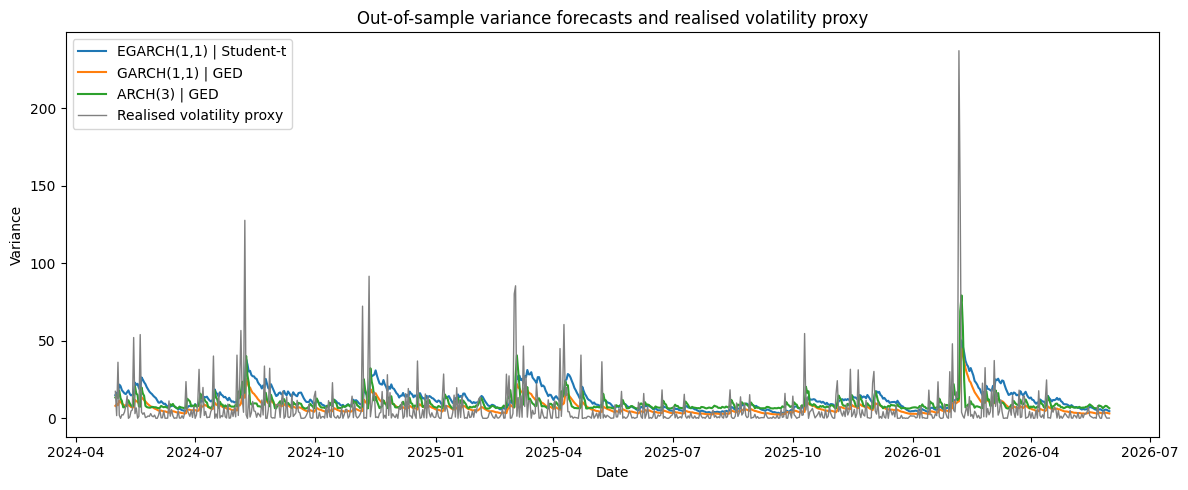

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for model_key in selected_model_keys:
    plt.plot(
        selected_forecast_data.index,
        selected_forecast_data[model_key],
        label=model_key,
        linewidth=1.5
    )

plt.plot(
    selected_forecast_data.index,
    selected_forecast_data["realised_volatility_proxy"],
    label="Realised volatility proxy",
    linewidth=1,
    color="grey",
)

plt.title("Out-of-sample variance forecasts and realised volatility proxy")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout()
plt.show()

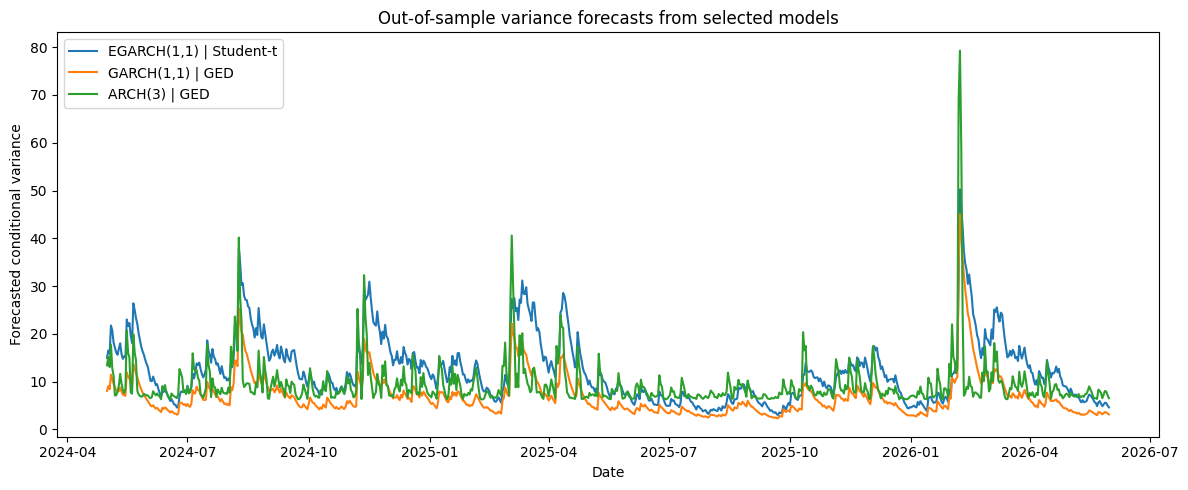

In [53]:
plt.figure(figsize=(12, 5))

for model_key in selected_model_keys:
    plt.plot(
        selected_forecast_data.index,
        selected_forecast_data[model_key],
        label=model_key,
        linewidth=1.5
    )

plt.title("Out-of-sample variance forecasts from selected models")
plt.xlabel("Date")
plt.ylabel("Forecasted conditional variance")
plt.legend()
plt.tight_layout()
plt.show()

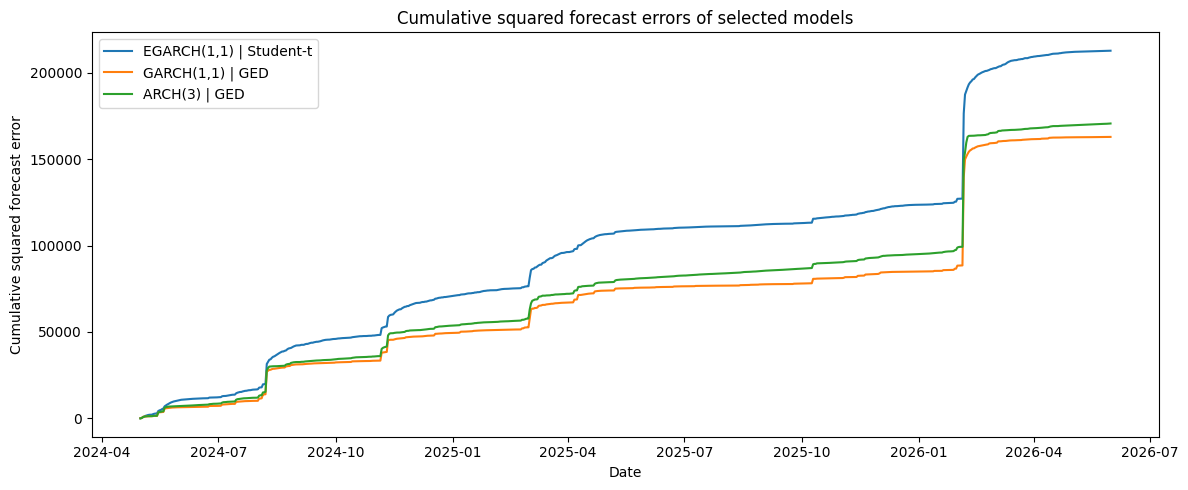

In [61]:
squared_forecast_errors = pd.DataFrame(index=returns_out.index)

for model_key in selected_model_keys:
    squared_forecast_errors[model_key] = (
        selected_forecast_data["realised_volatility_proxy"]
        - selected_forecast_data[model_key]
    ) ** 2

cumulative_squared_errors = squared_forecast_errors.cumsum()

plt.figure(figsize=(12, 5))

for model_key in selected_model_keys:
    plt.plot(
        cumulative_squared_errors.index,
        cumulative_squared_errors[model_key],
        label=model_key,
        linewidth=1.5
    )

plt.title("Cumulative squared forecast errors of selected models")
plt.xlabel("Date")
plt.ylabel("Cumulative squared forecast error")
plt.legend()
plt.tight_layout()
plt.show()

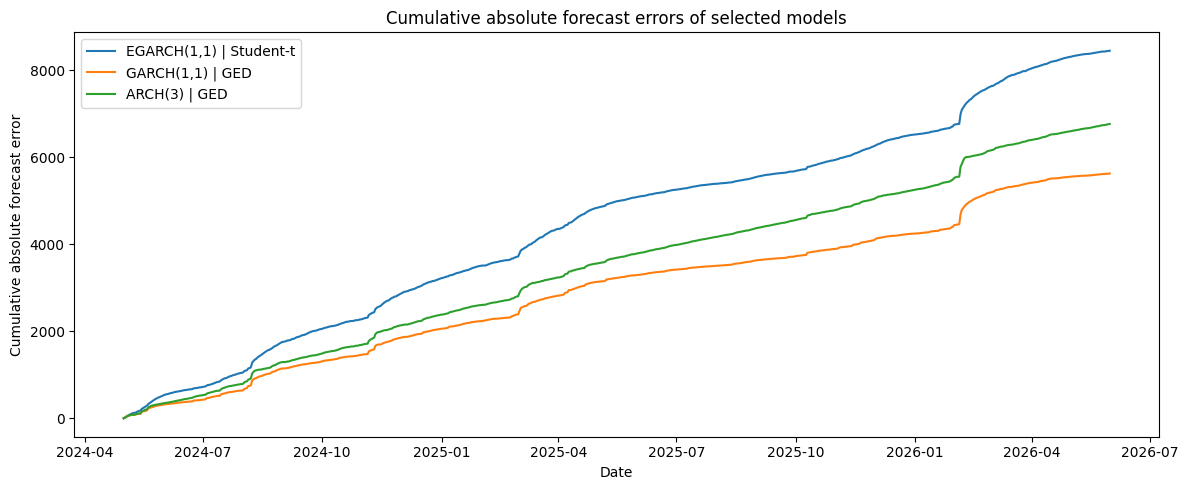

In [62]:
absolute_forecast_errors = pd.DataFrame(index=returns_out.index)

for model_key in selected_model_keys:
    absolute_forecast_errors[model_key] = (
        selected_forecast_data["realised_volatility_proxy"]
        - selected_forecast_data[model_key]
    ).abs()

cumulative_absolute_errors = absolute_forecast_errors.cumsum()

plt.figure(figsize=(12, 5))

for model_key in selected_model_keys:
    plt.plot(
        cumulative_absolute_errors.index,
        cumulative_absolute_errors[model_key],
        label=model_key,
        linewidth=1.5
    )

plt.title("Cumulative absolute forecast errors of selected models")
plt.xlabel("Date")
plt.ylabel("Cumulative absolute forecast error")
plt.legend()
plt.tight_layout()
plt.show()